In [1]:
! ls /kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000

ham10000_images_part_1	HAM10000_images_part_2	hmnist_28_28_RGB.csv
HAM10000_images_part_1	HAM10000_metadata.csv	hmnist_8_8_L.csv
ham10000_images_part_2	hmnist_28_28_L.csv	hmnist_8_8_RGB.csv


In [2]:
# Cell 1 — Install & Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.utils import make_grid, save_image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

Device: cuda
GPU: Tesla T4


In [3]:
# Cell 2 — Load Metadata & Map Image Paths
base_dir = '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000'
csv_path = os.path.join(base_dir, 'HAM10000_metadata.csv')

df = pd.read_csv(csv_path)

# Map every image_id → absolute file path
image_paths = {}
for part in ['HAM10000_images_part_1', 'HAM10000_images_part_2']:
    folder = os.path.join(base_dir, part)
    if os.path.exists(folder):
        for fname in os.listdir(folder):
            if fname.endswith('.jpg'):
                img_id = os.path.splitext(fname)[0]
                image_paths[img_id] = os.path.join(folder, fname)

df['path'] = df['image_id'].map(image_paths)

lesion_type_dict = {
    'nv'   : 'Melanocytic nevi',
    'mel'  : 'Melanoma',
    'bkl'  : 'Benign keratosis',
    'bcc'  : 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc' : 'Vascular lesions',
    'df'   : 'Dermatofibroma'
}
df['cell_type'] = df['dx'].map(lesion_type_dict)
df['age'].fillna(df['age'].mean(), inplace=True)

print(f"Total records: {len(df)}")
print(df['dx'].value_counts())

Total records: 10015
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


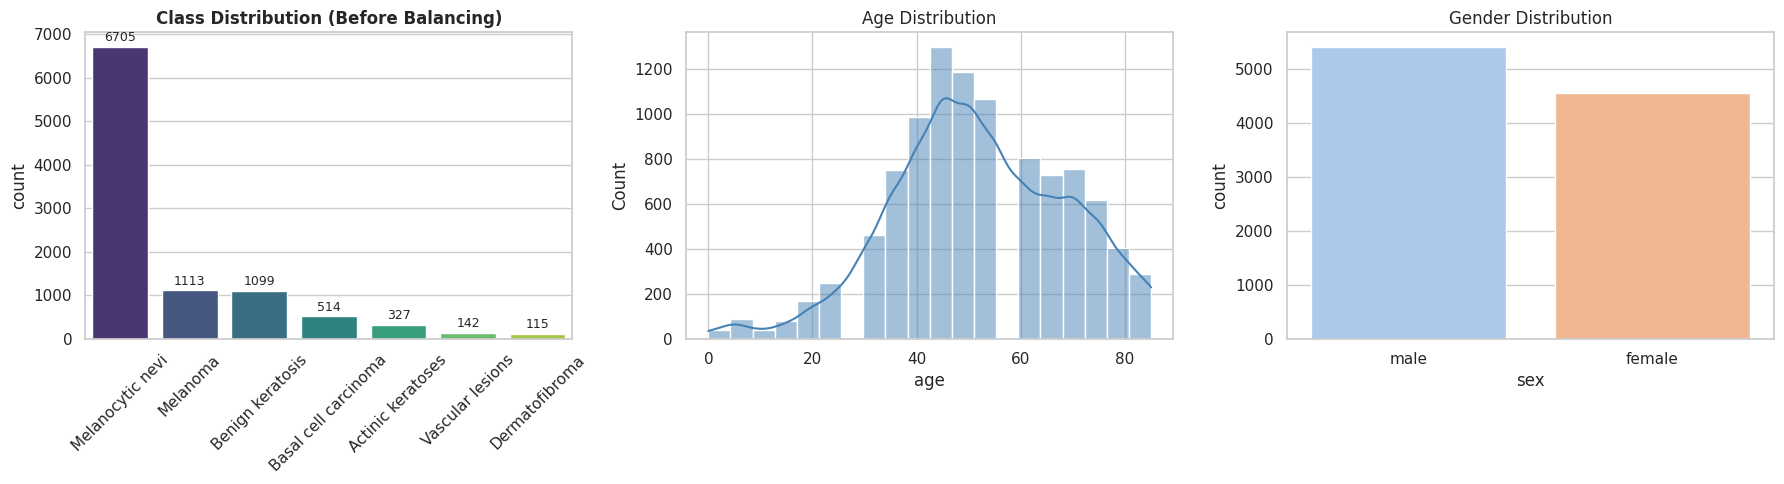

In [4]:
# Cell 3 — EDA: Class Distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Class counts
ax = sns.countplot(
    data=df, x='cell_type',
    order=df['cell_type'].value_counts().index,
    palette='viridis', ax=axes[0]
)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=9,
                xytext=(0, 4), textcoords='offset points')
axes[0].set_title('Class Distribution (Before Balancing)', fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)

# Age distribution
sns.histplot(df['age'], bins=20, kde=True, ax=axes[1], color='steelblue')
axes[1].set_title('Age Distribution')

# Sex distribution
sex_data = df[df['sex'] != 'unknown']
sns.countplot(data=sex_data, x='sex', ax=axes[2], palette='pastel')
axes[2].set_title('Gender Distribution')

plt.tight_layout()
plt.show()

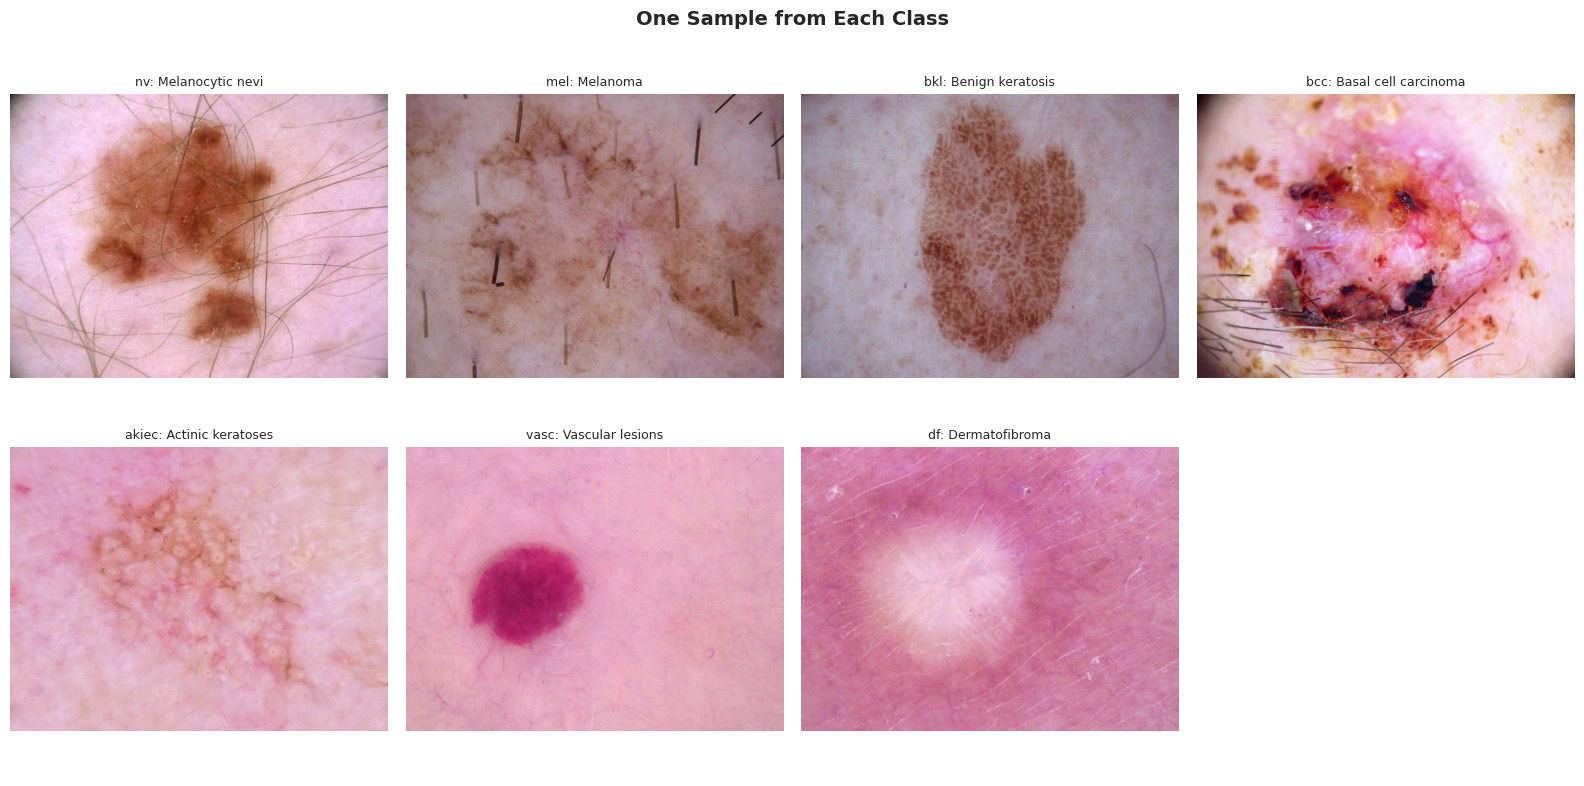

In [5]:
# Cell 4 — EDA: Sample Images Per Class
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, (code, name) in enumerate(lesion_type_dict.items()):
    sample_path = df[df['dx'] == code]['path'].dropna().sample(1).values[0]
    img = Image.open(sample_path)
    axes[i].imshow(img)
    axes[i].set_title(f"{code}: {name}", fontsize=9)
    axes[i].axis('off')

axes[7].axis('off')
plt.suptitle('One Sample from Each Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
# Cell 5 — Remove Duplicate Lesions & Train/Val Split
df_unique = df.drop_duplicates(subset='lesion_id').reset_index(drop=True)
print("After dedup:", df_unique['dx'].value_counts())

LABEL_MAP = {'nv': 0, 'mel': 1, 'bkl': 2, 'bcc': 3, 'akiec': 4, 'vasc': 5, 'df': 6}
INV_LABEL_MAP = {v: k for k, v in LABEL_MAP.items()}

train_df, val_df = train_test_split(
    df_unique, test_size=0.2, stratify=df_unique['dx'], random_state=42
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print(f"\nTrain: {len(train_df)} | Val: {len(val_df)}")
print("Train class counts:\n", train_df['dx'].value_counts())

# Target = largest class in train split
TARGET_COUNT = train_df['dx'].value_counts().max()
print(f"\nTarget samples per class: {TARGET_COUNT}")

After dedup: dx
nv       5403
bkl       727
mel       614
bcc       327
akiec     228
vasc       98
df         73
Name: count, dtype: int64

Train: 5976 | Val: 1494
Train class counts:
 dx
nv       4323
bkl       582
mel       491
bcc       262
akiec     182
vasc       78
df         58
Name: count, dtype: int64

Target samples per class: 4323


In [7]:
# Cell 6 — Copy Train Images into Per-Class Folders (for DCGAN)
import shutil

GAN_DATA_ROOT = '/kaggle/working/gan_data'
os.makedirs(GAN_DATA_ROOT, exist_ok=True)

minority_classes = [cls for cls in LABEL_MAP
                    if cls != 'nv']          # nv is majority, skip

for cls in minority_classes:
    cls_dir = os.path.join(GAN_DATA_ROOT, cls)
    os.makedirs(cls_dir, exist_ok=True)
    cls_df = train_df[train_df['dx'] == cls]
    for _, row in cls_df.iterrows():
        if pd.notna(row['path']) and os.path.exists(row['path']):
            shutil.copy(row['path'], cls_dir)
    print(f"{cls}: {len(os.listdir(cls_dir))} images in {cls_dir}")

mel: 491 images in /kaggle/working/gan_data/mel
bkl: 582 images in /kaggle/working/gan_data/bkl
bcc: 262 images in /kaggle/working/gan_data/bcc
akiec: 182 images in /kaggle/working/gan_data/akiec
vasc: 78 images in /kaggle/working/gan_data/vasc
df: 58 images in /kaggle/working/gan_data/df


In [8]:
# Cell 7 — DCGAN Architecture

Z_DIM   = 128      # noise vector size
IMG_SIZE = 64      # DCGAN output: 64×64
CHANNELS = 3

def weights_init(m):
    """Apply DCGAN weight init (mean=0, std=0.02) to Conv and BatchNorm layers."""
    classname = m.__class__.__name__
    if 'Conv' in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


class Generator(nn.Module):
    """
    Noise (Z_DIM) → 64×64 RGB image.
    Architecture: FC → reshape to 4×4 → 5× ConvTranspose2d blocks.
    """
    def __init__(self, z_dim=Z_DIM, channels=CHANNELS, feat=64):
        super().__init__()
        self.net = nn.Sequential(
            # z → 4×4
            nn.ConvTranspose2d(z_dim, feat * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(feat * 8),
            nn.ReLU(True),
            # 4 → 8
            nn.ConvTranspose2d(feat * 8, feat * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feat * 4),
            nn.ReLU(True),
            # 8 → 16
            nn.ConvTranspose2d(feat * 4, feat * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feat * 2),
            nn.ReLU(True),
            # 16 → 32
            nn.ConvTranspose2d(feat * 2, feat, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feat),
            nn.ReLU(True),
            # 32 → 64
            nn.ConvTranspose2d(feat, channels, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    """
    64×64 RGB image → real/fake scalar.
    Architecture: 5× Conv2d blocks → 1×1 output.
    """
    def __init__(self, channels=CHANNELS, feat=64):
        super().__init__()
        self.net = nn.Sequential(
            # 64 → 32
            nn.Conv2d(channels, feat, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # 32 → 16
            nn.Conv2d(feat, feat * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feat * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # 16 → 8
            nn.Conv2d(feat * 2, feat * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feat * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # 8 → 4
            nn.Conv2d(feat * 4, feat * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feat * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # 4 → 1
            nn.Conv2d(feat * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x).view(-1)


# Quick sanity check
G_test = Generator().to(device)
D_test = Discriminator().to(device)
z_test = torch.randn(4, Z_DIM, 1, 1).to(device)
img_test = G_test(z_test)
score_test = D_test(img_test)
print("Generator output:", img_test.shape)      # [4, 3, 64, 64]
print("Discriminator output:", score_test.shape) # [4]
del G_test, D_test, z_test, img_test, score_test

Generator output: torch.Size([4, 3, 64, 64])
Discriminator output: torch.Size([4])


In [9]:
# Cell 8 — Per-Class Image Dataset for GAN Training

gan_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])   # → [-1, 1]
])

class SingleClassDataset(Dataset):
    def __init__(self, folder, transform=None):
        self.paths = [
            os.path.join(folder, f)
            for f in os.listdir(folder)
            if f.endswith('.jpg')
        ]
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img

In [10]:
# Cell 9 — DCGAN Training Function

def train_dcgan(cls_name, cls_folder, epochs=300, batch_size=32, lr=0.0002):
    """
    Train a DCGAN on images from cls_folder.
    Returns trained Generator.
    Saves best checkpoint to /kaggle/working/gan_ckpt/{cls_name}_G.pth
    """
    print(f"\n{'='*55}")
    print(f"  Training DCGAN for class: [{cls_name.upper()}]")
    print(f"{'='*55}")

    # ---------- Data ----------
    dataset = SingleClassDataset(cls_folder, transform=gan_transforms)
    loader  = DataLoader(dataset, batch_size=batch_size,
                         shuffle=True, num_workers=2, drop_last=True)
    print(f"  Real images: {len(dataset)}")

    # ---------- Models ----------
    G = Generator(Z_DIM).to(device)
    D = Discriminator().to(device)
    G.apply(weights_init)
    D.apply(weights_init)

    criterion = nn.BCELoss()
    opt_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_D = optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))

    # Fixed noise for monitoring
    fixed_noise = torch.randn(16, Z_DIM, 1, 1, device=device)

    g_losses, d_losses = [], []
    best_g_loss = float('inf')

    ckpt_dir = '/kaggle/working/gan_ckpt'
    os.makedirs(ckpt_dir, exist_ok=True)

    for epoch in range(1, epochs + 1):
        G.train(); D.train()
        epoch_g, epoch_d = 0.0, 0.0

        for real_imgs in loader:
            real_imgs = real_imgs.to(device)
            bsz = real_imgs.size(0)

            real_labels = torch.ones(bsz, device=device) * 0.9   # label smoothing
            fake_labels = torch.zeros(bsz, device=device)

            # ---- Train Discriminator ----
            opt_D.zero_grad()
            out_real = D(real_imgs)
            loss_real = criterion(out_real, real_labels)

            z = torch.randn(bsz, Z_DIM, 1, 1, device=device)
            fake_imgs = G(z).detach()
            out_fake = D(fake_imgs)
            loss_fake = criterion(out_fake, fake_labels)

            loss_D = (loss_real + loss_fake) * 0.5
            loss_D.backward()
            opt_D.step()

            # ---- Train Generator (2× per D step) ----
            for _ in range(2):
                opt_G.zero_grad()
                z = torch.randn(bsz, Z_DIM, 1, 1, device=device)
                fake_imgs = G(z)
                out = D(fake_imgs)
                loss_G = criterion(out, torch.ones(bsz, device=device))
                loss_G.backward()
                opt_G.step()

            epoch_d += loss_D.item()
            epoch_g += loss_G.item()

        epoch_d /= len(loader)
        epoch_g /= len(loader)
        g_losses.append(epoch_g)
        d_losses.append(epoch_d)

        # Save best generator
        if epoch_g < best_g_loss:
            best_g_loss = epoch_g
            torch.save(G.state_dict(), os.path.join(ckpt_dir, f'{cls_name}_G.pth'))

        if epoch % 50 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d}/{epochs} | "
                  f"D_loss: {epoch_d:.4f} | G_loss: {epoch_g:.4f}")

    # ---- Loss curves ----
    plt.figure(figsize=(8, 3))
    plt.plot(g_losses, label='Generator', linewidth=1.2)
    plt.plot(d_losses, label='Discriminator', linewidth=1.2)
    plt.title(f'DCGAN Loss — {cls_name}')
    plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.legend(); plt.tight_layout(); plt.show()

    # ---- Preview grid ----
    G.eval()
    with torch.no_grad():
        samples = G(fixed_noise).cpu()
    samples = (samples * 0.5 + 0.5).clamp(0, 1)
    grid = make_grid(samples, nrow=4, padding=2)
    plt.figure(figsize=(8, 8))
    plt.imshow(grid.permute(1, 2, 0).numpy())
    plt.title(f'Generated samples — {cls_name}')
    plt.axis('off'); plt.show()

    # Load best checkpoint before returning
    G.load_state_dict(torch.load(os.path.join(ckpt_dir, f'{cls_name}_G.pth')))
    G.eval()
    return G

In [ ]:
# Cell 10 — Train DCGAN for Every Minority Class
# Runtime: ~10–15 min total on a Kaggle P100 GPU

trained_generators = {}

for cls in minority_classes:
    cls_folder = os.path.join(GAN_DATA_ROOT, cls)
    n_real = len(os.listdir(cls_folder))

    # Fewer real images → more epochs for exposure
    if n_real < 200:
        epochs = 500
    elif n_real < 600:
        epochs = 400
    else:
        epochs = 300

    G = train_dcgan(
        cls_name=cls,
        cls_folder=cls_folder,
        epochs=epochs,
        batch_size=32,
        lr=0.0002
    )
    trained_generators[cls] = G

print("\nAll GANs trained.")
print("Checkpoints saved to /kaggle/working/gan_ckpt/")


  Training DCGAN for class: [MEL]
  Real images: 491
  Epoch   1/400 | D_loss: 0.8354 | G_loss: 4.7381
  Epoch  50/400 | D_loss: 0.6593 | G_loss: 1.1351
  Epoch 100/400 | D_loss: 0.7156 | G_loss: 0.9140
  Epoch 150/400 | D_loss: 0.7043 | G_loss: 0.8676
  Epoch 200/400 | D_loss: 0.6988 | G_loss: 0.8589


In [ ]:
# Cell 11 — Generate Synthetic Images to Balance Dataset

SYN_ROOT = '/kaggle/working/synthetic'
os.makedirs(SYN_ROOT, exist_ok=True)

# De-normalise from [-1,1] back to [0,255] PIL image
def tensor_to_pil(t):
    t = (t * 0.5 + 0.5).clamp(0, 1)
    arr = (t.permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
    return Image.fromarray(arr)

syn_stats = {}

for cls in minority_classes:
    cls_real_count = len(train_df[train_df['dx'] == cls])
    n_needed       = TARGET_COUNT - cls_real_count

    out_dir = os.path.join(SYN_ROOT, cls)
    os.makedirs(out_dir, exist_ok=True)

    print(f"\n[{cls}] Real: {cls_real_count} | Need to generate: {n_needed}")

    G = trained_generators[cls]
    G.eval()

    generated = 0
    batch_size = 64

    with torch.no_grad():
        pbar = tqdm(total=n_needed, desc=f"Generating {cls}")
        while generated < n_needed:
            n = min(batch_size, n_needed - generated)
            z = torch.randn(n, Z_DIM, 1, 1, device=device)
            imgs = G(z)
            for i, img_tensor in enumerate(imgs):
                pil_img = tensor_to_pil(img_tensor)
                # Save as 224×224 directly so no resize needed in classifier DataLoader
                pil_img = pil_img.resize((224, 224), Image.BILINEAR)
                save_path = os.path.join(out_dir, f'{cls}_syn_{generated+i:05d}.jpg')
                pil_img.save(save_path, quality=92)
            generated += n
            pbar.update(n)
        pbar.close()

    syn_stats[cls] = {
        'real': cls_real_count,
        'synthetic': generated,
        'total': cls_real_count + generated
    }
    print(f"  Done — total after synthetic: {syn_stats[cls]['total']}")

print("\n\nSynthetic generation summary:")
print(pd.DataFrame(syn_stats).T.to_string())

In [ ]:
# Cell 12 — Visual Inspection of Synthetic Images

fig, axes = plt.subplots(len(minority_classes), 8, figsize=(18, 3 * len(minority_classes)))

for row_idx, cls in enumerate(minority_classes):
    syn_dir = os.path.join(SYN_ROOT, cls)
    syn_files = os.listdir(syn_dir)[:8]

    for col_idx, fname in enumerate(syn_files):
        img = Image.open(os.path.join(syn_dir, fname))
        axes[row_idx, col_idx].imshow(img)
        axes[row_idx, col_idx].axis('off')
        if col_idx == 0:
            axes[row_idx, col_idx].set_ylabel(cls, fontsize=11, fontweight='bold')

plt.suptitle('Synthetic Images (8 per class) — Visual Quality Check', fontsize=13)
plt.tight_layout()
plt.show()

# Check for mode collapse: are images visually diverse?
print("Inspect above: all 8 images per row should look DIFFERENT.")
print("If they look nearly identical, the GAN suffered mode collapse.")
print("Fix: increase epochs or lower lr to 0.0001 and retrain that class.")

In [ ]:
# Cell 13 — Dataset Class with Real + Synthetic Images

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

IMG_DIRS = [
    os.path.join(base_dir, 'HAM10000_images_part_1'),
    os.path.join(base_dir, 'HAM10000_images_part_2')
]

class HAMDatasetBalanced(Dataset):
    """
    Loads real HAM10000 images from img_dirs and synthetic images from syn_root.
    For nv (majority class), loads only real images.
    For all minority classes, loads real + synthetic to reach TARGET_COUNT.
    """
    def __init__(self, real_df, img_dirs, syn_root, transform=None, is_train=True):
        self.transform = transform
        self.records = []   # list of (path, label)

        # Build image_id → path map from HAM10000 folders
        path_map = {}
        for d in img_dirs:
            if not os.path.exists(d):
                continue
            for f in os.listdir(d):
                if f.endswith('.jpg'):
                    path_map[f.replace('.jpg', '')] = os.path.join(d, f)

        # --- Real images ---
        for _, row in real_df.iterrows():
            p = path_map.get(row['image_id'])
            if p:
                self.records.append((p, LABEL_MAP[row['dx']]))

        # --- Synthetic images (minority classes only) ---
        if is_train and syn_root:
            for cls in minority_classes:
                syn_dir = os.path.join(syn_root, cls)
                if not os.path.exists(syn_dir):
                    continue
                for f in os.listdir(syn_dir):
                    if f.endswith('.jpg'):
                        self.records.append(
                            (os.path.join(syn_dir, f), LABEL_MAP[cls])
                        )

        # Shuffle records
        import random
        random.seed(42)
        random.shuffle(self.records)

        # Print balance check
        from collections import Counter
        label_counts = Counter(lbl for _, lbl in self.records)
        print(f"  Dataset size: {len(self.records)}")
        for lbl, cnt in sorted(label_counts.items()):
            print(f"    {INV_LABEL_MAP[lbl]:6s}: {cnt}")

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        path, label = self.records[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label

In [ ]:
# Cell 14 — Build DataLoaders

print("Building training dataset (real + synthetic):")
train_dataset = HAMDatasetBalanced(
    real_df=train_df,
    img_dirs=IMG_DIRS,
    syn_root=SYN_ROOT,
    transform=train_transforms,
    is_train=True
)

print("\nBuilding validation dataset (real only):")
val_dataset = HAMDatasetBalanced(
    real_df=val_df,
    img_dirs=IMG_DIRS,
    syn_root=None,
    transform=val_transforms,
    is_train=False
)

train_loader = DataLoader(
    train_dataset, batch_size=32, shuffle=True,
    num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=32, shuffle=False,
    num_workers=2, pin_memory=True
)

print(f"\nTrain batches: {len(train_loader)} | Val batches: {len(val_loader)}")

In [ ]:
# Cell 15 — Build ConvNeXt-Base Classifier

NUM_CLASSES = 7

model = models.convnext_base(weights='IMAGENET1K_V1')

# Unfreeze all layers — full fine-tuning
for param in model.parameters():
    param.requires_grad = True

# Replace the classifier head
in_features = model.classifier[2].in_features
model.classifier[2] = nn.Linear(in_features, NUM_CLASSES)

model = model.to(device)

# With balanced data, uniform weights work well.
# Mild overweighting keeps focus on the hardest classes.
class_weights = torch.tensor([
    1.0,   # nv
    2.0,   # mel  — most clinically critical
    1.0,   # bkl
    1.2,   # bcc
    1.3,   # akiec
    1.5,   # vasc
    1.5    # df
], dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30, eta_min=1e-6)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")

In [ ]:
# Cell 16 — Training & Validation Loop Functions

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for imgs, labels in tqdm(loader, desc='  Train', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), 100.0 * correct / total


def validate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc='  Val  ', leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    acc = 100.0 * correct / total
    bal_acc = balanced_accuracy_score(all_labels, all_preds) * 100.0
    return total_loss / len(loader), acc, bal_acc, all_preds, all_labels


class EarlyStopping:
    def __init__(self, patience=6, metric='balanced_acc'):
        self.patience = patience
        self.counter  = 0
        self.best     = -float('inf')
        self.metric   = metric

    def __call__(self, score):
        if score > self.best:
            self.best    = score
            self.counter = 0
            return False
        self.counter += 1
        print(f"  EarlyStopping counter: {self.counter}/{self.patience}")
        return self.counter >= self.patience

In [ ]:
# Cell 17 — Run Training

EPOCHS    = 30
CKPT_PATH = '/kaggle/working/best_classifier.pth'

best_bal_acc = 0.0
early_stop   = EarlyStopping(patience=6)

history = {'train_loss': [], 'val_loss': [],
           'train_acc': [],  'val_acc': [], 'val_bal_acc': []}

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")

    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    vl_loss, vl_acc, vl_bal, preds, labels = validate(model, val_loader, criterion)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)
    history['val_bal_acc'].append(vl_bal)

    print(f"  Train  | Loss: {tr_loss:.4f}  Acc: {tr_acc:.2f}%")
    print(f"  Val    | Loss: {vl_loss:.4f}  Acc: {vl_acc:.2f}%  "
          f"Balanced Acc: {vl_bal:.2f}%  "
          f"LR: {scheduler.get_last_lr()[0]:.6f}")

    if vl_bal > best_bal_acc:
        best_bal_acc = vl_bal
        torch.save(model.state_dict(), CKPT_PATH)
        print(f"  ✅ Best model saved  (Balanced Acc: {vl_bal:.2f}%)")

    if early_stop(vl_bal):
        print("Early stopping triggered.")
        break

print(f"\nBest Balanced Accuracy: {best_bal_acc:.2f}%")

In [ ]:
# Cell 18 — Plot Training History

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(history['train_loss'], label='Train', linewidth=1.5)
axes[0].plot(history['val_loss'],   label='Val',   linewidth=1.5)
axes[0].set_title('Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')

axes[1].plot(history['train_acc'], label='Train', linewidth=1.5)
axes[1].plot(history['val_acc'],   label='Val',   linewidth=1.5)
axes[1].set_title('Accuracy (%)'); axes[1].legend(); axes[1].set_xlabel('Epoch')

axes[2].plot(history['val_bal_acc'], color='darkorange', linewidth=1.5)
axes[2].set_title('Validation Balanced Accuracy (%)'); axes[2].set_xlabel('Epoch')
axes[2].axhline(y=max(history['val_bal_acc']), color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
# Cell 19 — Final Evaluation on Validation Set

CLASS_NAMES = ['nv', 'mel', 'bkl', 'bcc', 'akiec', 'vasc', 'df']

# Load best checkpoint
model.load_state_dict(torch.load(CKPT_PATH))
_, final_acc, final_bal_acc, final_preds, final_labels = validate(
    model, val_loader, criterion
)

print(f"Final Val Accuracy        : {final_acc:.2f}%")
print(f"Final Balanced Accuracy   : {final_bal_acc:.2f}%")
print(f"\nClassification Report:\n")
print(classification_report(final_labels, final_preds, target_names=CLASS_NAMES))

In [ ]:
# Cell 20 — Confusion Matrix

cm = confusion_matrix(final_labels, final_preds)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            cmap='Blues', ax=axes[0], linewidths=0.5)
axes[0].set_title('Confusion Matrix — Raw Counts', fontweight='bold')
axes[0].set_ylabel('True Label'); axes[0].set_xlabel('Predicted Label')

# Row-normalised (recall per class)
sns.heatmap(cm_pct, annot=True, fmt='.1f',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            cmap='Blues', ax=axes[1], vmin=0, vmax=100, linewidths=0.5)
axes[1].set_title('Confusion Matrix — Row % (Recall per Class)', fontweight='bold')
axes[1].set_ylabel('True Label'); axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

In [ ]:
# Cell 21 — Per-Class Recall Bar Chart
from sklearn.metrics import recall_score

recalls = recall_score(final_labels, final_preds, average=None)
recall_df = pd.DataFrame({
    'Class': CLASS_NAMES,
    'Recall': recalls,
    'N_samples': [sum(l == i for l in final_labels) for i in range(NUM_CLASSES)]
})
recall_df = recall_df.sort_values('Recall')

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#d73027' if r < 0.70 else '#fc8d59' if r < 0.80 else '#4dac26'
          for r in recall_df['Recall']]
bars = ax.barh(recall_df['Class'], recall_df['Recall'], color=colors)

for bar, val, n in zip(bars, recall_df['Recall'], recall_df['N_samples']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}  (n={n})', va='center', fontsize=10)

ax.set_xlim(0, 1.2)
ax.axvline(x=0.80, color='black', linestyle='--', alpha=0.4, label='0.80 target')
ax.set_title('Per-Class Recall (Val Set) — After GAN Balancing', fontweight='bold')
ax.set_xlabel('Recall')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Cell 22 — Compare Baseline vs GAN Results

baseline = {
    'nv': 0.93, 'mel': 0.58, 'bkl': 0.72,
    'bcc': 0.92, 'akiec': 0.78, 'vasc': 0.90, 'df': 0.67
}
gan_recalls = dict(zip(CLASS_NAMES, recalls))

compare_df = pd.DataFrame({
    'Class': CLASS_NAMES,
    'Baseline (oversample)': [baseline[c] for c in CLASS_NAMES],
    'GAN balanced':          [gan_recalls[c] for c in CLASS_NAMES]
})

x = np.arange(len(CLASS_NAMES))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, compare_df['Baseline (oversample)'],
       width, label='Baseline (oversampling)', color='#5a9dcc', alpha=0.85)
ax.bar(x + width/2, compare_df['GAN balanced'],
       width, label='GAN balanced', color='#4dac26', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES)
ax.set_ylabel('Recall')
ax.set_ylim(0, 1.1)
ax.axhline(y=0.80, color='red', linestyle='--', alpha=0.4, label='0.80 target')
ax.legend()
ax.set_title('Recall Comparison: Oversampling vs DCGAN Balancing', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nBaseline balanced acc : 0.7855")
print(f"GAN balanced acc       : {final_bal_acc/100:.4f}")
print(f"Delta                  : +{(final_bal_acc/100 - 0.7855):.4f}")